In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset load karo
df3 = df3 = pd.read_csv('/content/california_housing[1].csv')
print("Dataset loaded!")
print("Shape:", df3.shape)
df3.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/california_housing[1].csv'

In [ ]:
import os
print(os.listdir('/content'))

In [11]:
from google.colab import files
uploaded = files.upload()

Saving california_housing.csv to california_housing.csv


In [12]:
import pandas as pd
df3 = pd.read_csv('california_housing.csv')
print("Loaded! Shape:", df3.shape)
df3.head()

Loaded! Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [13]:
print(df3.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [14]:
# Features aur target select karo
features = ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X = df3[features]
y = df3['MedInc']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 1.2514957943752711
R² Score: 0.5574640908701853


In [15]:
# Clustering ke liye 2 numeric columns select karo
from sklearn.preprocessing import StandardScaler

cluster_features = df3[['Latitude', 'Longitude']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("Data scaled! Shape:", X_scaled.shape)

Data scaled! Shape: (20640, 2)


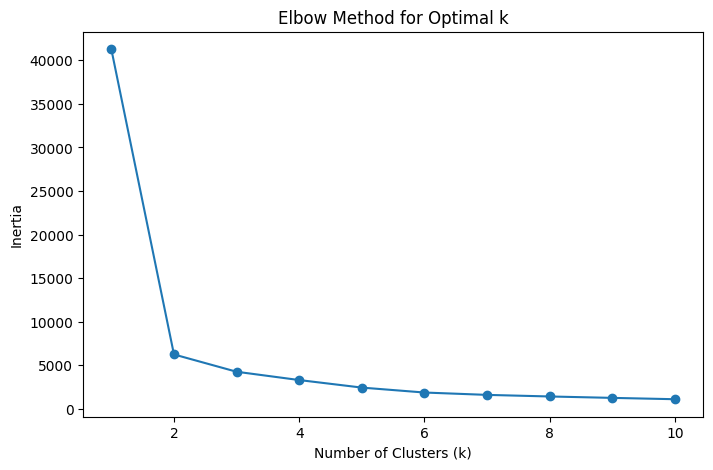

In [16]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

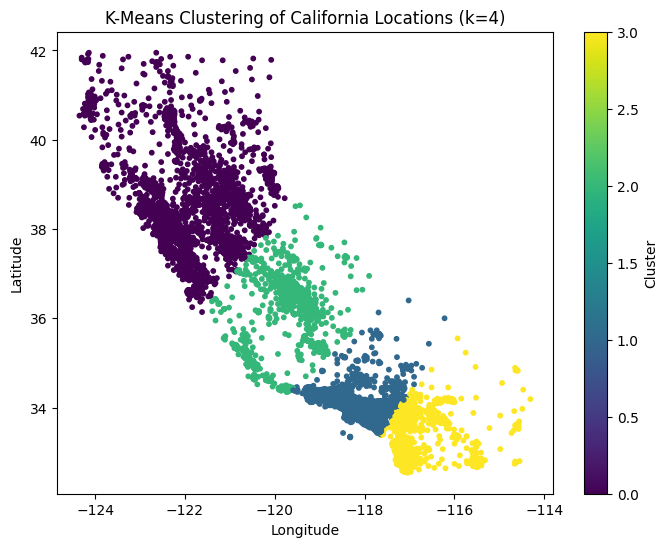

In [17]:
# Final KMeans model with chosen k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df3['Cluster'] = kmeans.labels_

# Visualize clusters
plt.figure(figsize=(8,6))
plt.scatter(df3['Longitude'], df3['Latitude'], c=df3['Cluster'], cmap='viridis', s=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of California Locations (k=4)')
plt.colorbar(label='Cluster')
plt.show()

## Regression & Clustering Summary

*Regression:* I trained a Linear Regression model to predict Median Income (MedInc) using features like HouseAge, AveRooms, Population, and location data. The model achieved an RMSE of 1.25 and R² score of 0.56, meaning it explains about 56% of the variance in income. The moderate score suggests income depends on other factors not captured here (e.g., employment type, local economy).

*Clustering:* Using the elbow method on Latitude/Longitude, I found k=4 to be a reasonable number of clusters. The resulting K-Means clusters map closely onto real California regions — likely representing the Bay Area, Central Valley, Los Angeles metro, and the southeastern/desert region. This shows housing data naturally groups by geography.

*Next steps:* I could improve the regression model by adding more features (e.g., proximity to coast, income diversity by region) or trying a Random Forest Regressor for better accuracy.